In [1]:

import pandas as pd


In [2]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [5]:
df.set_index("customerID", inplace=True)

In [6]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null 

In [8]:
df['TotalCharges']= df['TotalCharges'].replace(' ',pd.NA)

In [9]:
df['TotalCharges']= pd.to_numeric(df['TotalCharges'],errors='coerce')

In [10]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
df.dropna(subset='TotalCharges', axis=0,inplace=True)

In [12]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df.index.duplicated().sum()

np.int64(0)

In [14]:
df['Churn']= df['Churn'].str.strip().map({'No':0,'Yes':1})

In [15]:
df['Churn']

customerID
7590-VHVEG    0
5575-GNVDE    0
3668-QPYBK    1
7795-CFOCW    0
9237-HQITU    1
             ..
6840-RESVB    0
2234-XADUH    0
4801-JZAZL    0
8361-LTMKD    1
3186-AJIEK    0
Name: Churn, Length: 7032, dtype: int64

In [16]:
(df['Churn']==1).sum()

np.int64(1869)

In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [18]:
df.describe(include='object')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365


In [19]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [20]:
df['Churn'].value_counts(normalize=True)*100

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

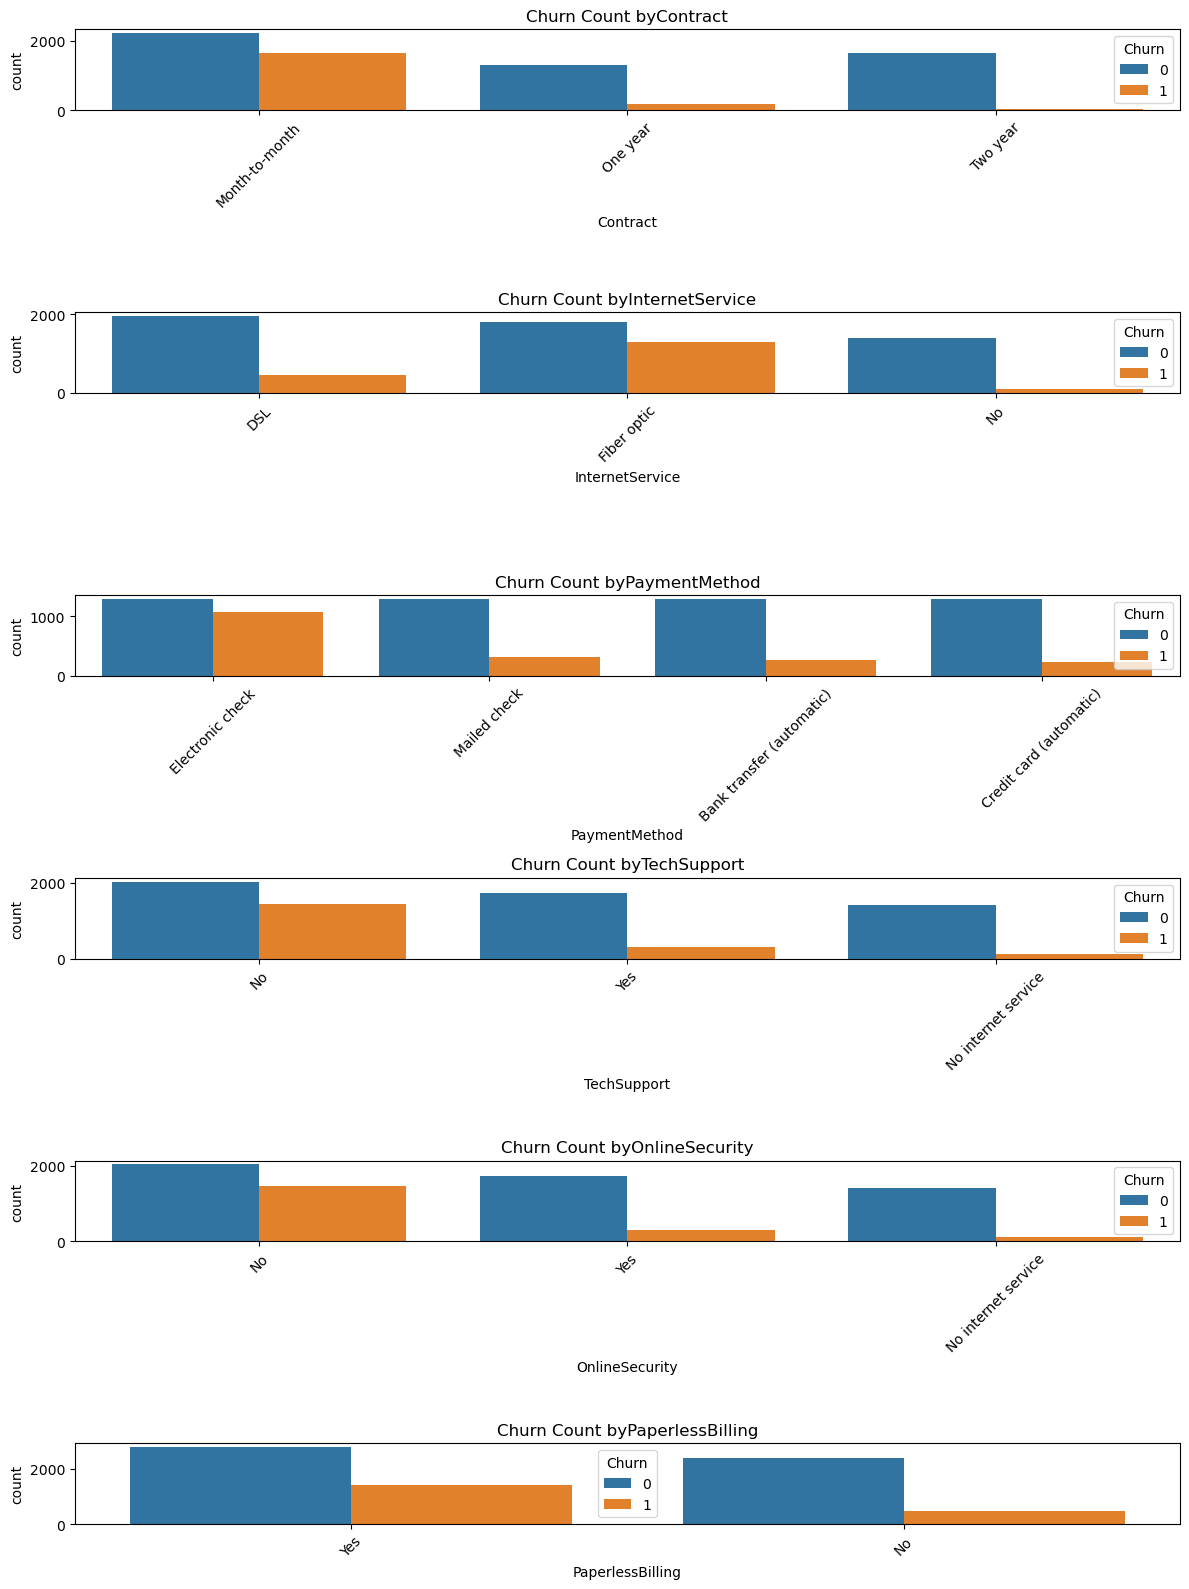

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,16))
useful_cat_features =[
    'Contract','InternetService','PaymentMethod','TechSupport','OnlineSecurity',
    'PaperlessBilling'
]

for i, col in enumerate(useful_cat_features,1):
    plt.subplot(len(useful_cat_features),1,i)
    sns.countplot(data=df,x=col,hue='Churn')
    plt.title(f'Churn Count by{col}')
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()


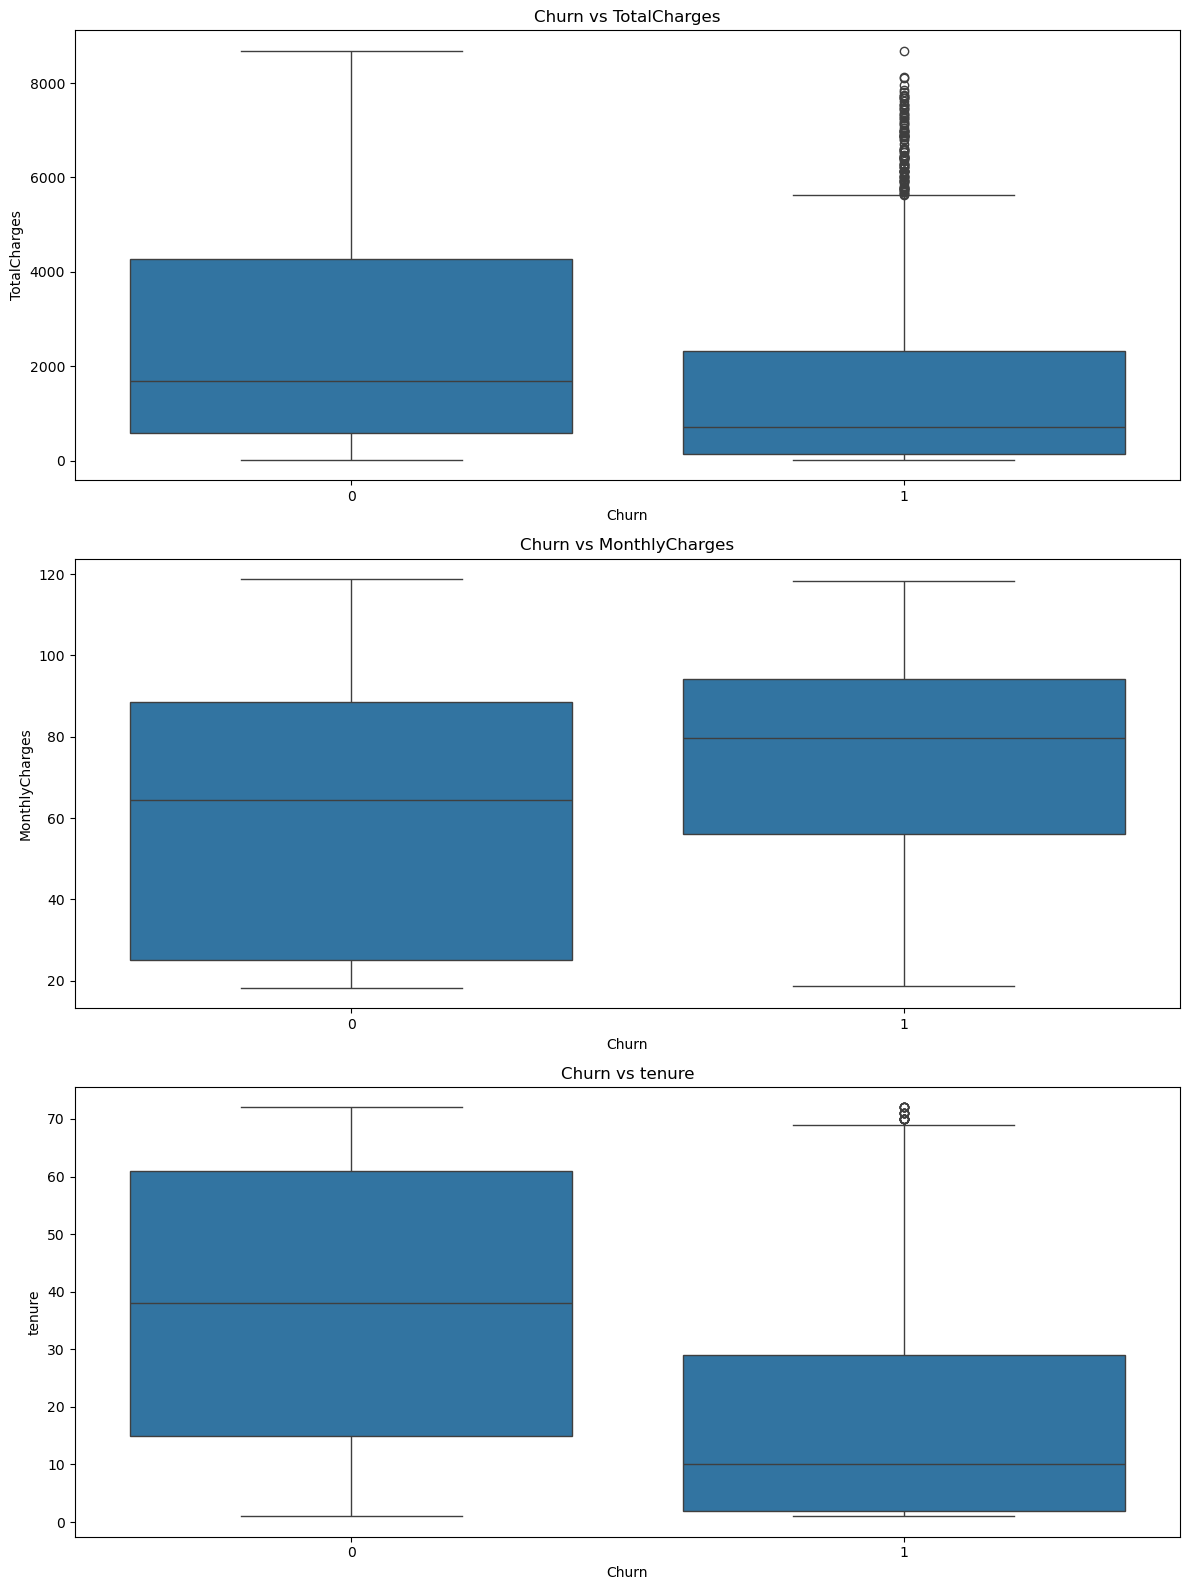

In [22]:
num_features=['TotalCharges','MonthlyCharges','tenure']
plt.figure(figsize=(12,16))

for i, col in enumerate(num_features,1):
    plt.subplot(len(num_features),1,i)
    sns.boxplot(data=df,x='Churn',y=col)
    plt.title(f'Churn vs {col}')
    plt.tight_layout()

plt.show()

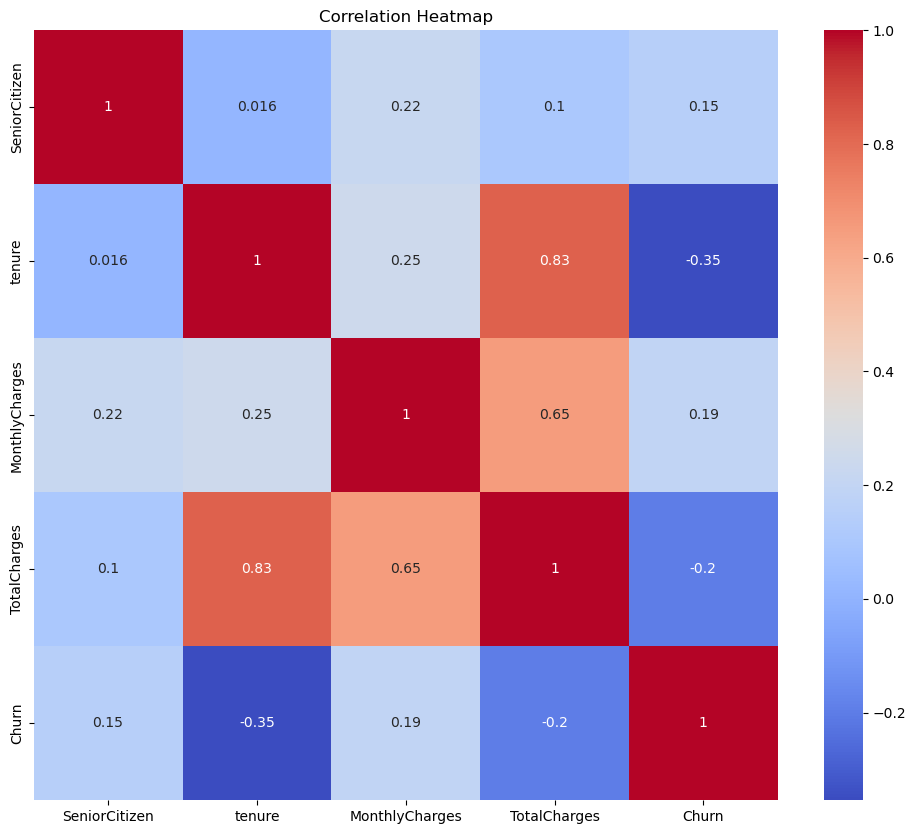

In [23]:
df_numeric = df.select_dtypes(include=['number'])
corr= df_numeric.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [24]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [25]:
binary_features = [col for col in cat_cols if df[col].nunique()==2]
multi_class_features = [col for col in cat_cols if df[col].nunique()>2]

In [26]:
binary_features

['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

In [27]:
multi_class_features

['MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod']

In [28]:
summary = pd.DataFrame({
    'Feature': cat_cols,
    'Unique Values': [df[col].nunique() for col in cat_cols],
    'Type':['Binary' if df[col].nunique()==2 else 'Multi-Class' for col in cat_cols]
})

summary.sort_values(by="Unique Values")

,Feature,Unique Values,Type
0,gender,2,Binary
1,Partner,2,Binary
2,Dependents,2,Binary
3,PhoneService,2,Binary
13,PaperlessBilling,2,Binary
4,MultipleLines,3,Multi-Class
5,InternetService,3,Multi-Class
6,OnlineSecurity,3,Multi-Class
7,OnlineBackup,3,Multi-Class
8,DeviceProtection,3,Multi-Class


In [29]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in binary_features:
    df[col]=le.fit_transform(df[col])
    

In [30]:
df[binary_features].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling
customerID,,,,,
7590-VHVEG,0,1,0,0,1
5575-GNVDE,1,0,0,1,0
3668-QPYBK,1,0,0,1,1
7795-CFOCW,1,0,0,0,0
9237-HQITU,0,0,0,1,1


In [31]:
df= pd.get_dummies(df,columns=multi_class_features)

In [32]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,...,True,False,False,True,False,False,False,False,True,False
5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,False,False,False,False,True
3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,...,True,False,False,True,False,False,False,False,False,True
7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,True,False,True,False,False,False
9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,...,True,False,False,True,False,False,False,False,True,False


In [33]:
pd.set_option('display.max_columns', None)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
customerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,False,True,False,True,False,False,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False
5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,0,True,False,False,True,False,False,False,False,True,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True
3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,True,False,False,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True
7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,False,True,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,False,True,False,True,False,False,False
9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,True,False,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False


In [34]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols]= df[bool_cols].astype('int')

In [35]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
customerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0
5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1
3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1
7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,1,0,0,0
9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0


In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols= ['tenure','TotalCharges','MonthlyCharges']
df[numeric_cols]= scaler.fit_transform(df[numeric_cols])

In [37]:
df[numeric_cols]

,tenure,TotalCharges,MonthlyCharges
customerID,,,
7590-VHVEG,-1.280248,-0.994194,-1.161694
5575-GNVDE,0.064303,-0.173740,-0.260878
3668-QPYBK,-1.239504,-0.959649,-0.363923
7795-CFOCW,0.512486,-0.195248,-0.747850
9237-HQITU,-1.239504,-0.940457,0.196178
...,...,...,...
6840-RESVB,-0.343137,-0.129180,0.664868
2234-XADUH,1.612573,2.241056,1.276493
4801-JZAZL,-0.872808,-0.854514,-1.170004


In [38]:
y= df['Churn']
X=df.drop('Churn',axis=1)


In [39]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42)

Handle Class Imbalance in Training Data

Since our dataset is imbalanced — with around 73% 'No' and 27% 'Yes' for Churn — it's important to balance the classes in the training set. This ensures the model does not become biased toward the majority class.


In [41]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state= 42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train,y_train)

In [43]:
 y_train_resampled.value_counts()

Churn
1    4130
0    4130
Name: count, dtype: int64

In [48]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 3.7 MB/s eta 0:00:19
   - -------------------------------------- 2.1/69.5 MB 6.3 MB/s eta 0:00:11
   -- ------------------------------------- 5.0/69.5 MB 9.2 MB/s eta 0:00:07
   ---- ----------------------------------- 7.6/69.5 MB 10.2 MB/s eta 0:00:07
   ------ --------------------------------- 11.0/69.5 MB 11.6 MB/s eta 0:00:06
   -------- ------------------------------- 14.7/69.5 MB 13.0 MB/s eta 0:00:05
   ----------- ---------------------------- 19.7/69.5 MB 14.4 MB/s eta 0:00:04
   -------------- ------------------------- 24.9/69.5 MB 15.9 MB/s eta 0:00:03
   ----------------- ---------------------- 30.7/69.5 MB 17.3 MB/s eta 0:00:03
   --------------------- ------------------ 37.7/69.5 MB 19.2 MB/s eta 0:00:02
   ------------------------- -------------- 44.8/69.5 MB 20.6 MB/s eta 0:00:0

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

In [53]:
models = {
    'Logistic Regression': LogisticRegression(solver='liblinear',random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss',random_state=42)
}

In [55]:
for name,model in models.items():
    pipe=Pipeline([
        ('scaler',StandardScaler()),
        ('model',model)
    ])

    pipe.fit(X_train_resampled,y_train_resampled)

    y_pred = pipe.predict(X_test)
    print(f'Model: {name}')

    print(classification_report(y_test,y_pred))
    

Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1033
           1       0.56      0.68      0.62       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.78      1407

Model: Random Forest
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      1033
           1       0.54      0.59      0.56       374

    accuracy                           0.76      1407
   macro avg       0.69      0.70      0.70      1407
weighted avg       0.77      0.76      0.76      1407

Model: XGBoost
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1033
           1       0.55      0.60      0.57       374

    accuracy                           0.76      1407
   macro avg       0.70      0.71      0.70      1407
weighted av